# Data ingestion and basic usage
This notebook shows how to fetch data and compute spreads using the `src/pairs_trading` package.

In [1]:
from datetime import datetime

from pairs_trading.data.fetcher import fetch_pair_data, fetch_price_data
from pairs_trading.data.schemas import Asset, Pair
from pairs_trading.data.spread import compute_spread

In [2]:
asset = Asset(symbol="^GSPC", name="S&P 500")

data = fetch_price_data(
    asset=asset,
    start_date=datetime(2020, 1, 1),
    end_date=datetime(2020, 12, 31),
)

print(data.df.head())

                                  open         high          low        close  \
Date                                                                            
2020-01-02 00:00:00-05:00  3244.669922  3258.139893  3235.530029  3257.850098   
2020-01-03 00:00:00-05:00  3226.360107  3246.149902  3222.340088  3234.850098   
2020-01-06 00:00:00-05:00  3217.550049  3246.840088  3214.639893  3246.280029   
2020-01-07 00:00:00-05:00  3241.860107  3244.909912  3232.429932  3237.179932   
2020-01-08 00:00:00-05:00  3238.590088  3267.070068  3236.669922  3253.050049   

                               volume  
Date                                   
2020-01-02 00:00:00-05:00  3459930000  
2020-01-03 00:00:00-05:00  3484700000  
2020-01-06 00:00:00-05:00  3702460000  
2020-01-07 00:00:00-05:00  3435910000  
2020-01-08 00:00:00-05:00  3726840000  


In [3]:
# Define a pair and fetch aligned price data
asset_a = Asset(symbol="MSFT", name="Microsoft")
asset_b = Asset(symbol="AAPL", name="Apple")

start = datetime(2022, 1, 1)
end = datetime(2023, 1, 1)

data_a, data_b = fetch_pair_data(asset_a, asset_b, start, end)

data_a.df.head()

,open,high,low,close,volume
Date,,,,,
2022-01-03 00:00:00-05:00,335.350006,338.000000,329.779999,334.750000,28865100
2022-01-04 00:00:00-05:00,334.829987,335.200012,326.119995,329.010010,32674300
2022-01-05 00:00:00-05:00,325.859985,326.070007,315.980011,316.380005,40054300
2022-01-06 00:00:00-05:00,313.149994,318.700012,311.489990,313.880005,39646100
2022-01-07 00:00:00-05:00,314.149994,316.500000,310.089996,314.040009,32720000


In [4]:
# Compute spread + z-score
pair = Pair(asset_a=asset_a, asset_b=asset_b)
spread_data = compute_spread(pair, data_a, data_b, zscore_lookback=20)

spread_data.hedge_ratio, spread_data.half_life

(1.70239533348443, 17.794837132727775)

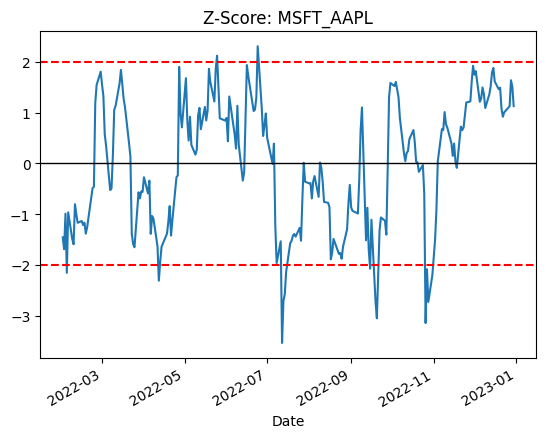

In [5]:
# Plot z-score
import matplotlib.pyplot as plt

ax = spread_data.z_score.plot(title=f"Z-Score: {pair.pair_id}")
ax.axhline(0, color="black", linewidth=1)
ax.axhline(2, color="red", linestyle="--")
ax.axhline(-2, color="red", linestyle="--")
plt.show()